# Forecast Using the TiRex Family



foundationforecast ships a single `TiRex` class that transparently supports both TiRex 1.0 and TiRex 2.0 foundation models from NX-AI. Pass the Hugging Face `repo_id` to select the checkpoint:

- **TiRex 1.0** (`NX-AI/TiRex`): univariate zero-shot forecasting with xLSTM.
- **TiRex 2.0** (`NX-AI/TiRex-2`): extends TiRex to multivariate forecasting and covariates (this notebook uses the univariate API).

*Requirements*:

    - Python >= 3.11
    - TiRex 1.0 runs on CPU and CUDA (including macOS).
    - TiRex 2.0 runs on CPU, CUDA, and Apple MPS. On CUDA it uses Triton kernels for speed; on CPU and MPS it uses native PyTorch kernels (no Triton required).

In this example we compare TiRex 1.0 and TiRex 2.0 on event pageview data.



## Import libraries



In [1]:
import sys

import pandas as pd

from foundationforecast import FoundationForecast

if sys.version_info < (3, 11):
    raise RuntimeError("TiRex requires Python >= 3.11")


/Users/azul/projects/foundationforecast/.venv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
INFO:datasets:JAX version 0.7.1 available.


## Load the dataset

The DataFrame must include at least the following columns:
- unique_id: Unique identifier for each time series (string)
- ds: Date column (datetime format)
- y: Target variable for forecasting (float format)

The pandas frequency will be inferred from the ds column, if not provided.
If the seasonality is not provided, it will be inferred based on the frequency.
If the horizon is not set, it will default to 2 times the inferred seasonality.



In [2]:
df = pd.read_csv(
    "https://timecopilot.s3.amazonaws.com/public/data/events_pageviews.csv",
    parse_dates=["ds"],
)
df.head()


,unique_id,ds,y
0,Oktoberfest,2020-01-31,25376
1,Oktoberfest,2020-02-29,28470
2,Oktoberfest,2020-03-31,23816
3,Oktoberfest,2020-04-30,46186
4,Oktoberfest,2020-05-31,31213


## Plot the data



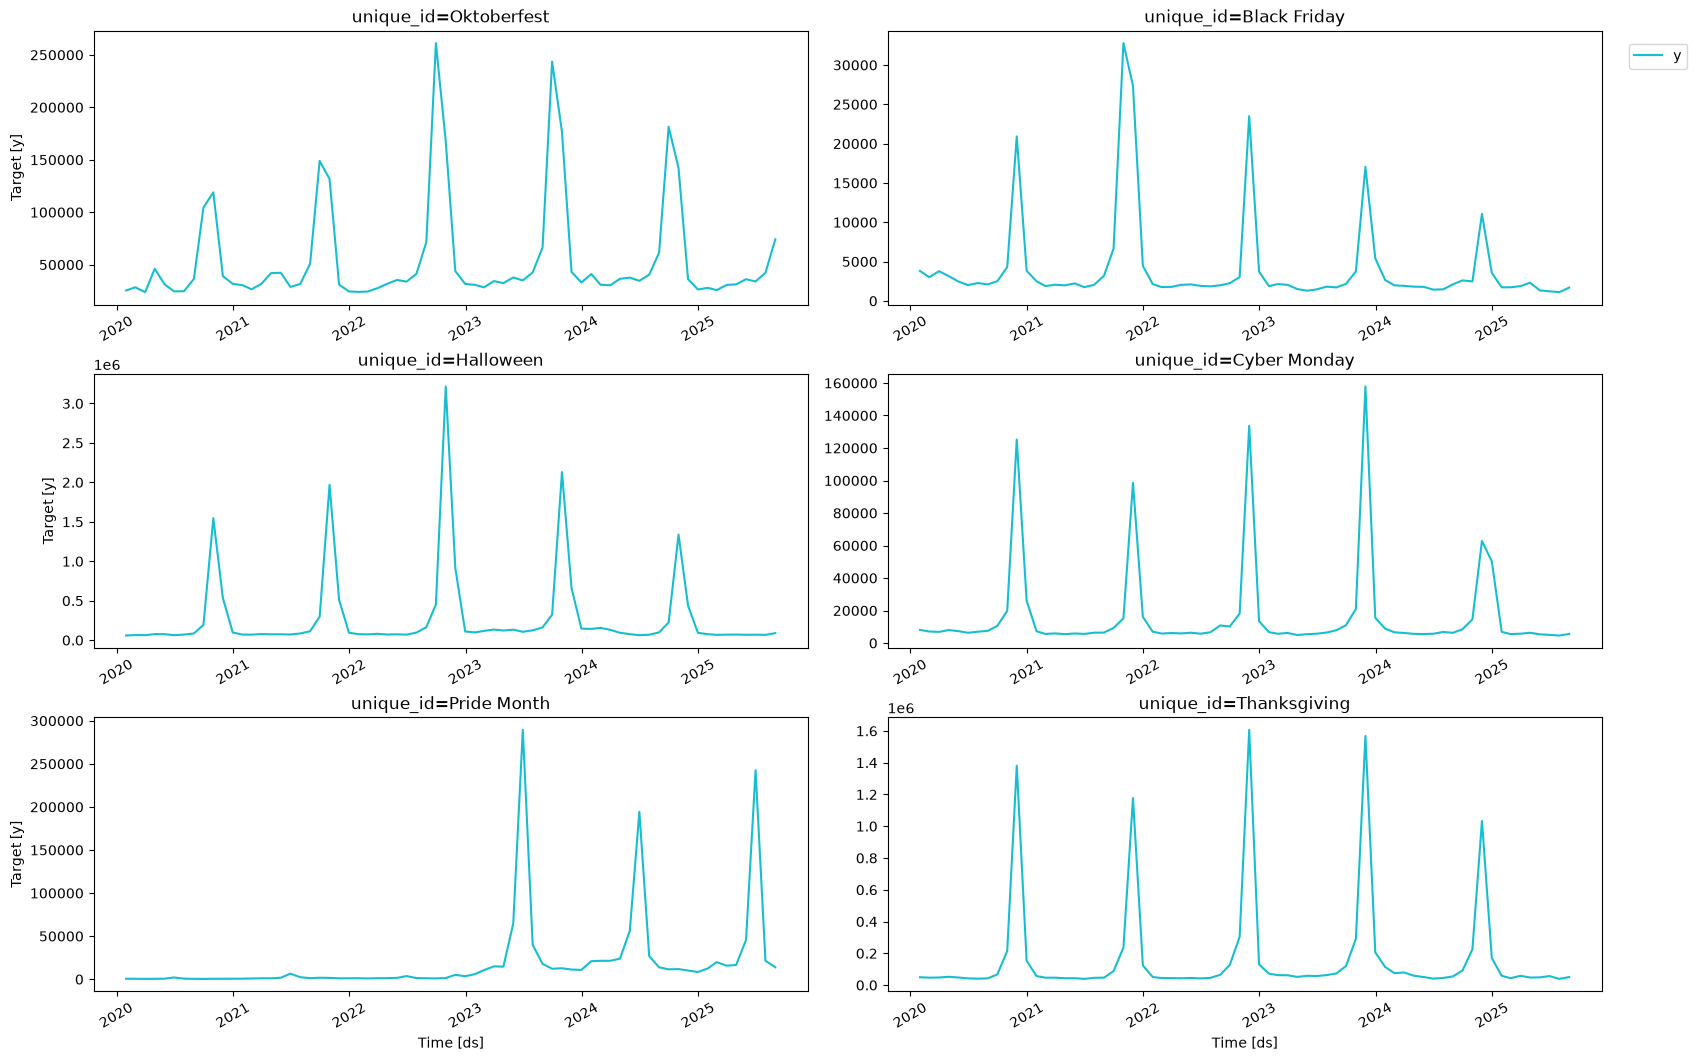

In [3]:
FoundationForecast.plot(df)


## Import the models



In [4]:
from foundationforecast.models import TiRex



## Create a FoundationForecast

We compare TiRex 1.0 (`NX-AI/TiRex`) with TiRex 2.0 (`NX-AI/TiRex-2`) Each model gets a distinct `alias` so its forecasts are easy to identify.



In [5]:
models = [
    TiRex(repo_id="NX-AI/TiRex", alias="NX-AI/TiRex"),
    TiRex(repo_id="NX-AI/TiRex-2", alias="NX-AI/TiRex-2"),]

ff = FoundationForecast(models=models)


## Generate forecast

You can optionally specify the following parameters:
- freq: The frequency of your data (e.g., 'D' for daily, 'M' for monthly)
- h: The forecast horizon, which is the number of periods to predict
- seasonality: The seasonal period of your data, which can be inferred if not provided



In [6]:
level = [20, 40, 50, 60, 80] 
cv_df = ff.cross_validation(df=df, h=12, level=level)


0it [00:00, ?it/s]Warning: You are sending unauthenticated requests to the HF Hub. Please set a HF_TOKEN to enable higher rate limits and faster downloads.
100%|██████████| 1/1 [00:00<00:00,  1.44it/s]
1it [00:01,  1.11s/it]
Fetching 2 files: 100%|██████████| 2/2 [00:00<00:00, 1544.29it/s]
W0924 12:50:44.397000 5039 torch/_inductor/utils.py:1731] [0/0] Not enough SMs to use max_autotune_gemm mode
1it [00:12, 12.37s/it]


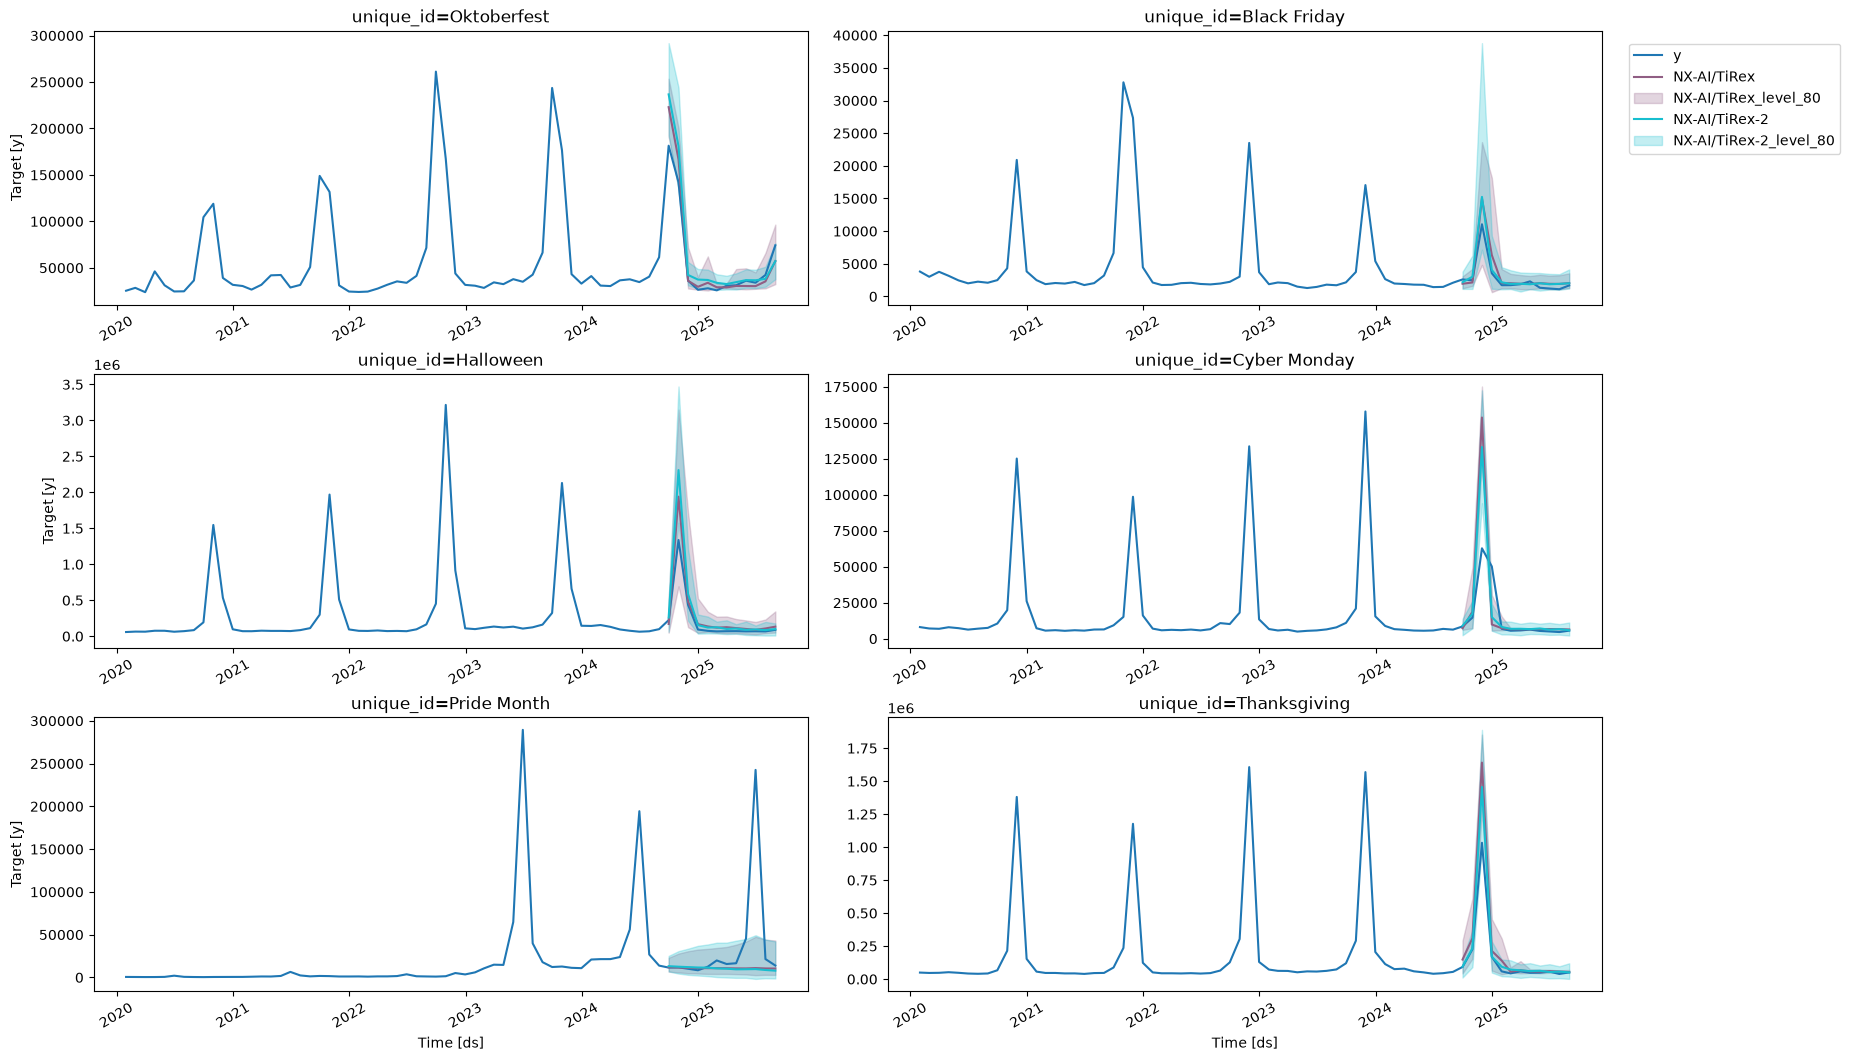

In [7]:
ff.plot(df, cv_df.drop(columns=["cutoff", "y"]), level=[80])


In [8]:
cv_df.head()


,unique_id,ds,cutoff,y,NX-AI/TiRex,NX-AI/TiRex-lo-20,NX-AI/TiRex-hi-20,NX-AI/TiRex-lo-40,NX-AI/TiRex-hi-40,NX-AI/TiRex-lo-50,...,NX-AI/TiRex-2-lo-20,NX-AI/TiRex-2-hi-20,NX-AI/TiRex-2-lo-40,NX-AI/TiRex-2-hi-40,NX-AI/TiRex-2-lo-50,NX-AI/TiRex-2-hi-50,NX-AI/TiRex-2-lo-60,NX-AI/TiRex-2-hi-60,NX-AI/TiRex-2-lo-80,NX-AI/TiRex-2-hi-80
0,Black Friday,2024-09-30,2024-08-31,2607,1948.055908,1791.597412,2102.441162,1641.423340,2290.069336,1558.584595,...,2007.525269,2386.087158,1797.989258,2651.129639,1672.743713,2853.507202,1547.498169,3055.884766,1158.590332,3792.830322
1,Black Friday,2024-10-31,2024-08-31,2470,2139.084717,2028.829834,2318.470459,1967.522217,2578.440674,1905.705322,...,2549.032471,3529.206299,2100.748047,4125.935547,1885.738098,4540.721191,1670.728149,4955.506836,1153.969971,6252.913086
2,Black Friday,2024-11-30,2024-08-31,11058,14989.021484,13045.734375,16617.699219,10284.201172,18399.558594,8953.109863,...,12578.720703,18615.710938,10446.683594,23053.326172,9592.568359,26174.834961,8738.453125,29296.343750,7159.876465,38791.203125
3,Black Friday,2024-12-31,2024-08-31,3548,6331.335938,4327.646484,8178.669434,2777.951660,10953.730469,2179.010498,...,3267.265625,4959.096680,2586.488281,6039.037109,2268.324341,6722.615479,1950.160400,7406.193848,1182.048340,9297.125977
4,Black Friday,2025-01-31,2024-08-31,1724,2055.054932,1852.060547,2230.285156,1660.915771,2496.528809,1577.482544,...,1882.615479,2497.839844,1650.357422,2935.709961,1538.235840,3241.027344,1426.114258,3546.344727,1090.071289,4475.763672


## Evaluation



In [9]:
from functools import partial

from utilsforecast.evaluation import evaluate
from utilsforecast.losses import mase, scaled_crps


In [10]:
eval_df = evaluate(
    cv_df.drop(columns=["cutoff"]),
    train_df=df.query("ds <= '2024-08-31'"),
    metrics=[partial(mase, seasonality=12), scaled_crps],
    level=level,
)
eval_df.groupby("metric").mean(numeric_only=True).T.sort_values(
    by="scaled_crps"
).round(3)


metric,mase,scaled_crps
NX-AI/TiRex-2,1.530,0.383
NX-AI/TiRex,1.727,0.407
